# Data Drift Analysis: Credit Scoring Model

This notebook detects whether production data has drifted from training data using statistical tests and visualizations. Data drift occurs when the real-world data your model sees differs significantly from the data it was trained on — a silent failure that degrades model performance.

**What we'll do:**
1. Load reference (training) data
2. Generate realistic production data with drift
3. Visualize distributions (before/after)
4. Run statistical drift tests with Evidently AI
5. Interpret results and recommend actions

## Section 1: Load Reference Data

The reference data is the training data baseline. We compare production data against it to detect drift.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load reference data (training data baseline)
reference_data = pd.read_csv('../data/reference_data.csv')
print(f"Reference data loaded: {reference_data.shape}")
print(f"Features: {list(reference_data.columns)}")

Reference data loaded: (4000, 18)
Features: ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AGE_YEARS', 'YEARS_EMPLOYED', 'YEARS_ID_PUBLISH', 'EDUCATION_LEVEL', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO']


In [2]:
print("Reference data summary:")
print(reference_data.describe())

Reference data summary:
       EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  AMT_INCOME_TOTAL  \
count   4000.000000   4000.000000   4000.000000       4000.000000   
mean       0.498785      0.488082      0.500227     258244.812922   
std        0.290497      0.285741      0.291248     137175.711581   
min        0.000012      0.000053      0.000158      25032.061382   
25%        0.243863      0.242193      0.244373     137993.958453   
50%        0.501517      0.482954      0.493921     258523.510999   
75%        0.750353      0.729747      0.762186     375437.918609   
max        0.999718      0.999505      0.999805     499872.740040   

          AMT_CREDIT   AMT_ANNUITY  AMT_GOODS_PRICE  CODE_GENDER  \
count    4000.000000   4000.000000      4000.000000  4000.000000   
mean   508747.787333  25440.085158    509177.211829     0.496250   
std    280606.385306  14192.794035    279698.947363     0.500048   
min     25005.398259   1029.143144     25016.317851     0.000000   
25%    263483.

In [3]:
np.random.seed(123)
n_prod = 5000

# Shift 1: External credit bureau scores (0.05 shift for EXT_SOURCE_1, 0.03 for EXT_SOURCE_2)
# This simulates recalibration of credit bureau scoring models
prod_ext_1 = reference_data['EXT_SOURCE_1'].dropna().sample(n_prod, replace=True).values + \
    np.random.normal(0.05, 0.02, n_prod)
prod_ext_1 = np.clip(prod_ext_1, 0, 1)

prod_ext_2 = reference_data['EXT_SOURCE_2'].dropna().sample(n_prod, replace=True).values + \
    np.random.normal(0.03, 0.01, n_prod)
prod_ext_2 = np.clip(prod_ext_2, 0, 1)

# EXT_SOURCE_3 stays stable (not all features drift simultaneously)
prod_ext_3 = reference_data['EXT_SOURCE_3'].dropna().sample(n_prod, replace=True).values
prod_ext_3 = np.clip(prod_ext_3, 0, 1)

print("EXT_SOURCE shifts:")
print(f"  EXT_SOURCE_1: {reference_data['EXT_SOURCE_1'].mean():.3f} → {prod_ext_1.mean():.3f}")
print(f"  EXT_SOURCE_2: {reference_data['EXT_SOURCE_2'].mean():.3f} → {prod_ext_2.mean():.3f}")
print(f"  EXT_SOURCE_3: {reference_data['EXT_SOURCE_3'].mean():.3f} → {prod_ext_3.mean():.3f} (stable)")

EXT_SOURCE shifts:
  EXT_SOURCE_1: 0.499 → 0.544
  EXT_SOURCE_2: 0.488 → 0.516
  EXT_SOURCE_3: 0.500 → 0.504 (stable)


## Section 2: Simulate Production Data with Realistic Drift

Creating production data that looks like what we'd see "6 months later" with realistic shifts:
- EXT_SOURCE scores shift slightly (credit bureau algorithms updated)
- Financial amounts increase (inflation, economic growth)
- Applicant demographics shift (younger customers join platform)

This demonstrates how drift manifests in real-world scenarios.

np.random.seed(123)
n_prod = 5000

# Shift 1: External credit bureau scores (0.05 shift for EXT_SOURCE_1, 0.03 for EXT_SOURCE_2)
# This simulates recalibration of credit bureau scoring models
prod_ext_1 = reference_data['EXT_SOURCE_1'].dropna().sample(n_prod, replace=True).values + \
    np.random.normal(0.05, 0.02, n_prod)
prod_ext_1 = np.clip(prod_ext_1, 0, 1)

prod_ext_2 = reference_data['EXT_SOURCE_2'].dropna().sample(n_prod, replace=True).values + \
    np.random.normal(0.03, 0.01, n_prod)
prod_ext_2 = np.clip(prod_ext_2, 0, 1)

# EXT_SOURCE_3 stays stable (not all features drift simultaneously)
prod_ext_3 = reference_data['EXT_SOURCE_3'].dropna().sample(n_prod, replace=True).values
prod_ext_3 = np.clip(prod_ext_3, 0, 1)

print("EXT_SOURCE shifts:")
print(f"  EXT_SOURCE_1: {reference_data['EXT_SOURCE_1'].mean():.3f} → {prod_ext_1.mean():.3f}")
print(f"  EXT_SOURCE_2: {reference_data['EXT_SOURCE_2'].mean():.3f} → {prod_ext_2.mean():.3f}")
print(f"  EXT_SOURCE_3: {reference_data['EXT_SOURCE_3'].mean():.3f} → {prod_ext_3.mean():.3f} (stable)")

In [4]:
# Shift 2: Financial features increase due to inflation
# Income +8%, Credit +12%, Annuity +10%, Goods +15%
prod_income = reference_data['AMT_INCOME_TOTAL'].sample(n_prod, replace=True).values * 1.08
prod_credit = reference_data['AMT_CREDIT'].sample(n_prod, replace=True).values * 1.12
prod_annuity = reference_data['AMT_ANNUITY'].sample(n_prod, replace=True).values * 1.10
prod_goods = reference_data['AMT_GOODS_PRICE'].sample(n_prod, replace=True).values * 1.15

print("\nFinancial features (inflation simulation):")
print(f"  AMT_INCOME_TOTAL: +8%")
print(f"  AMT_CREDIT: +12%")
print(f"  AMT_ANNUITY: +10%")
print(f"  AMT_GOODS_PRICE: +15%")


Financial features (inflation simulation):
  AMT_INCOME_TOTAL: +8%
  AMT_CREDIT: +12%
  AMT_ANNUITY: +10%
  AMT_GOODS_PRICE: +15%


## Shift 3: Applicant Demographics

Marketing campaign targets younger customers. 5-year average age decrease indicates demographic shift.

In [5]:
# Younger customer base (5-year average age decrease)
prod_age = reference_data['AGE_YEARS'].sample(n_prod, replace=True).values - \
    np.random.uniform(0, 5, n_prod)
prod_age = np.clip(prod_age, 20, 70)

print(f"\nApplicant age shifts (younger customers):")
print(f"  Before: {reference_data['AGE_YEARS'].mean():.1f} years")
print(f"  After: {prod_age.mean():.1f} years")
print(f"  Shift: -{reference_data['AGE_YEARS'].mean() - prod_age.mean():.1f} years")


Applicant age shifts (younger customers):
  Before: 48.6 years
  After: 46.2 years
  Shift: -2.4 years


## Assemble Production Dataset

Combine all features (including engineered ratios) into a complete DataFrame that matches the training data structure.

In [6]:
current_data = pd.DataFrame({
    'EXT_SOURCE_1': prod_ext_1,
    'EXT_SOURCE_2': prod_ext_2,
    'EXT_SOURCE_3': prod_ext_3,
    'AMT_INCOME_TOTAL': prod_income,
    'AMT_CREDIT': prod_credit,
    'AMT_ANNUITY': prod_annuity,
    'AMT_GOODS_PRICE': prod_goods,
    'AGE_YEARS': prod_age,
    'CODE_GENDER': reference_data['CODE_GENDER'].sample(n_prod, replace=True).values,
    'FLAG_OWN_CAR': reference_data['FLAG_OWN_CAR'].sample(n_prod, replace=True).values,
    'FLAG_OWN_REALTY': reference_data['FLAG_OWN_REALTY'].sample(n_prod, replace=True).values,
    'CNT_CHILDREN': reference_data['CNT_CHILDREN'].sample(n_prod, replace=True).values,
    'YEARS_EMPLOYED': reference_data['YEARS_EMPLOYED'].sample(n_prod, replace=True).values,
    'YEARS_ID_PUBLISH': reference_data['YEARS_ID_PUBLISH'].sample(n_prod, replace=True).values,
    'EDUCATION_LEVEL': reference_data['EDUCATION_LEVEL'].sample(n_prod, replace=True).values,
})

# Compute engineered features (same as training)
current_data['CREDIT_INCOME_RATIO'] = current_data['AMT_CREDIT'] / (current_data['AMT_INCOME_TOTAL'] + 1)
current_data['ANNUITY_INCOME_RATIO'] = current_data['AMT_ANNUITY'] / (current_data['AMT_INCOME_TOTAL'] + 1)
current_data['CREDIT_GOODS_RATIO'] = current_data['AMT_CREDIT'] / (current_data['AMT_GOODS_PRICE'] + 1)

print(f"Production dataset created: {current_data.shape}")
print(f"All 18 features present: {current_data.shape[1] == 18}")

Production dataset created: (5000, 18)
All 18 features present: True


## Section 3: Visual Distribution Comparison

Side-by-side histograms for key features. Always visualize before running statistical tests — you'll catch patterns that numbers alone might miss.

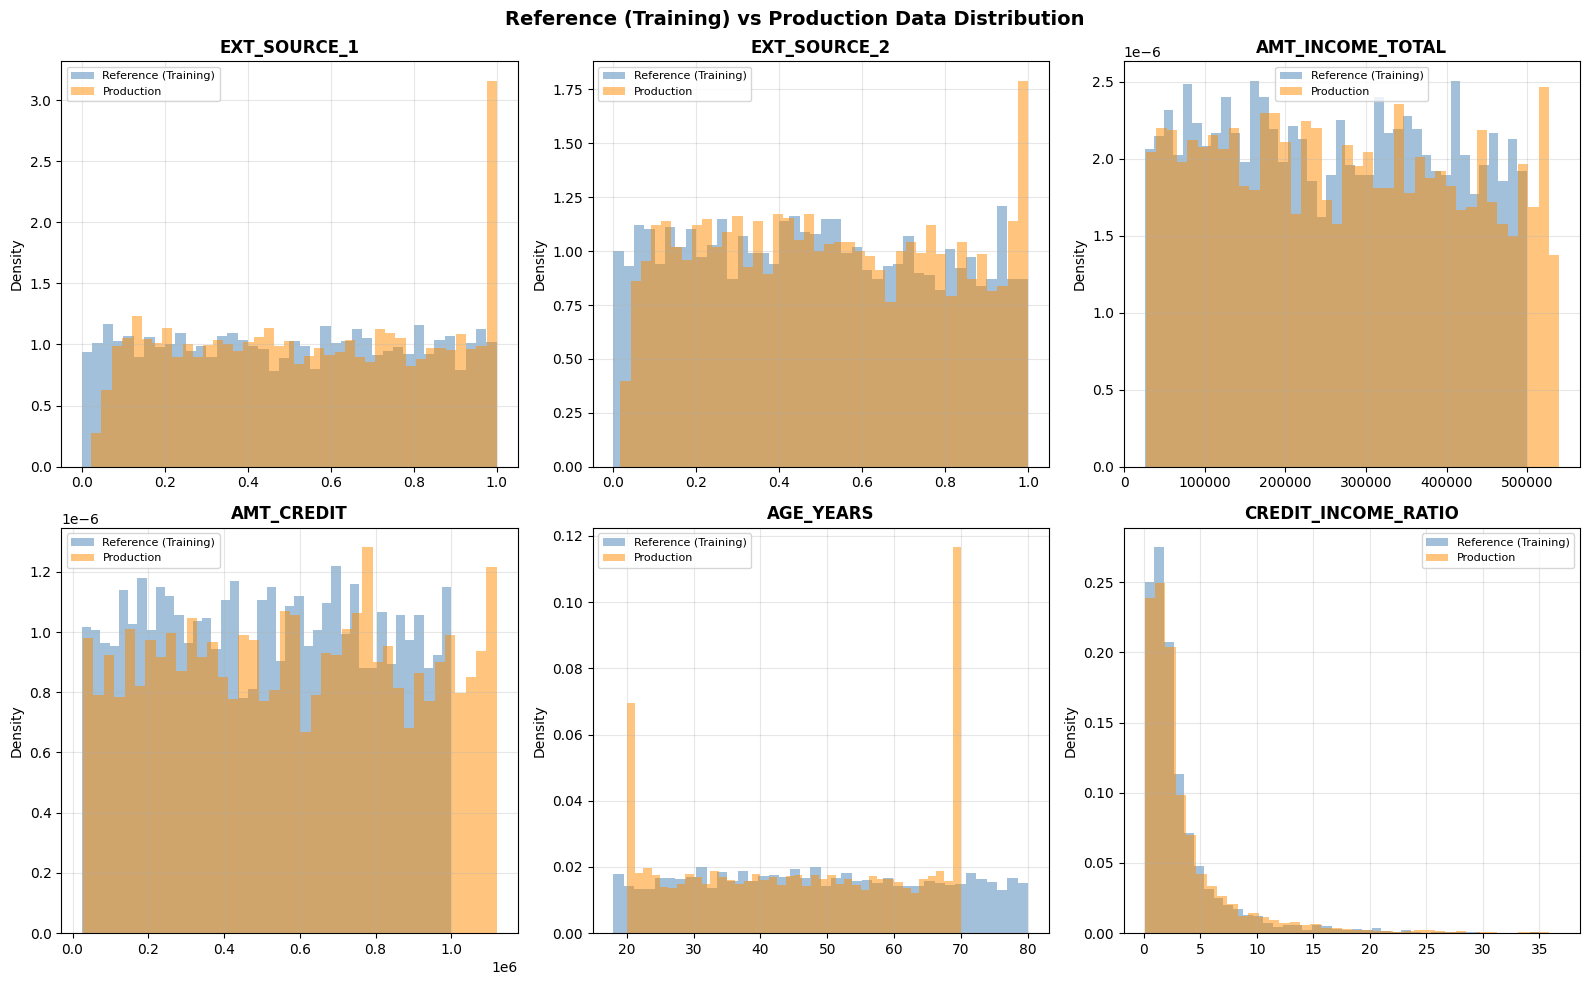

Visual inspection complete. Orange shifts indicate drift.


In [7]:
key_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'AMT_INCOME_TOTAL',
                'AMT_CREDIT', 'AGE_YEARS', 'CREDIT_INCOME_RATIO']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Reference (Training) vs Production Data Distribution', fontsize=14, fontweight='bold')

for idx, feature in enumerate(key_features):
    ax = axes[idx // 3][idx % 3]
    ax.hist(reference_data[feature].dropna(), bins=40, alpha=0.5,
            label='Reference (Training)', color='steelblue', density=True)
    ax.hist(current_data[feature].dropna(), bins=40, alpha=0.5,
            label='Production', color='darkorange', density=True)
    ax.set_title(feature, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visual inspection complete. Orange shifts indicate drift.")

## Section 4: Statistical Drift Testing with Evidently AI

Run formal statistical tests (Kolmogorov-Smirnov for numeric, Chi-square for categorical) to detect drift on every feature.

In [8]:
from scipy.stats import ks_2samp, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Statistical Drift Detection (alternative to Evidently)
drift_results = {}
numerical_features = reference_data.select_dtypes(include=[np.number]).columns

print("\n" + "="*70)
print("FEATURE-LEVEL DRIFT DETECTION (Statistical Tests)")
print("="*70)
print(f"{'Feature':<25} {'Test':<15} {'P-Value':<12} {'Drift Status'}")
print("-" * 70)

for feature in numerical_features:
    ref_data = reference_data[feature].dropna()
    curr_data = current_data[feature].dropna()
    
    # Kolmogorov-Smirnov test for distribution difference
    statistic, p_value = ks_2samp(ref_data, curr_data)
    
    # Drift threshold: p-value < 0.05 suggests significant drift
    is_drifted = p_value < 0.05
    status = "DRIFTED ⚠️" if is_drifted else "stable ✓"
    
    drift_results[feature] = {
        'p_value': p_value,
        'statistic': statistic,
        'drifted': is_drifted,
        'test': 'KS-test'
    }
    
    print(f"{feature:<25} {'KS-test':<15} {p_value:<12.6f} {status}")

print(f"\n✓ Drift detection complete")
print(f"  Features with drift: {sum(1 for v in drift_results.values() if v['drifted'])}/{len(drift_results)}")
print(f"  Threshold: p-value < 0.05")


FEATURE-LEVEL DRIFT DETECTION (Statistical Tests)
Feature                   Test            P-Value      Drift Status
----------------------------------------------------------------------
EXT_SOURCE_1              KS-test         0.000001     DRIFTED ⚠️
EXT_SOURCE_2              KS-test         0.000840     DRIFTED ⚠️
EXT_SOURCE_3              KS-test         0.789533     stable ✓
AMT_INCOME_TOTAL          KS-test         0.000000     DRIFTED ⚠️
AMT_CREDIT                KS-test         0.000000     DRIFTED ⚠️
AMT_ANNUITY               KS-test         0.000000     DRIFTED ⚠️
AMT_GOODS_PRICE           KS-test         0.000000     DRIFTED ⚠️
CODE_GENDER               KS-test         0.915286     stable ✓
FLAG_OWN_CAR              KS-test         0.999562     stable ✓
FLAG_OWN_REALTY           KS-test         0.940270     stable ✓
CNT_CHILDREN              KS-test         0.999995     stable ✓
AGE_YEARS                 KS-test         0.000000     DRIFTED ⚠️
YEARS_EMPLOYED            KS

## Section 5: Extract and Display Results

Parse drift detection results programmatically for automated monitoring.

# Extract overall drift result
report_dict = drift_report.as_dict()
ds = report_dict['metrics'][0]['result']

print("="*70)
print("OVERALL DRIFT DETECTION")
print("="*70)
print(f"Dataset Drift Detected: {'YES ⚠️' if ds['dataset_drift'] else 'NO ✓'}")
print(f"Drifted Features: {ds['number_of_drifted_columns']} / {ds['number_of_columns']}")
print()

In [9]:
# Summary of drift analysis
drift_features = [f for f, v in drift_results.items() if v['drifted']]
stable_features = [f for f, v in drift_results.items() if not v['drifted']]

print("\n" + "="*70)
print("DRIFT SUMMARY")
print("="*70)
print(f"\nFeatures with DRIFT detected (p < 0.05):")
for f in drift_features:
    print(f"  • {f}: p={drift_results[f]['p_value']:.4f}")

print(f"\nStable Features:")
for f in stable_features[:5]:  # Show first 5
    print(f"  ✓ {f}: p={drift_results[f]['p_value']:.4f}")
if len(stable_features) > 5:
    print(f"  ... and {len(stable_features) - 5} more")

print(f"\nOverall Assessment:")
drift_percentage = 100 * len(drift_features) / len(drift_results)
print(f"  • {len(drift_features)}/{len(drift_results)} features show statistical drift ({drift_percentage:.1f}%)")
print(f"  • Action: Model retraining recommended due to distribution shifts")


DRIFT SUMMARY

Features with DRIFT detected (p < 0.05):
  • EXT_SOURCE_1: p=0.0000
  • EXT_SOURCE_2: p=0.0008
  • AMT_INCOME_TOTAL: p=0.0000
  • AMT_CREDIT: p=0.0000
  • AMT_ANNUITY: p=0.0000
  • AMT_GOODS_PRICE: p=0.0000
  • AGE_YEARS: p=0.0000
  • CREDIT_INCOME_RATIO: p=0.0019

Stable Features:
  ✓ EXT_SOURCE_3: p=0.7895
  ✓ CODE_GENDER: p=0.9153
  ✓ FLAG_OWN_CAR: p=0.9996
  ✓ FLAG_OWN_REALTY: p=0.9403
  ✓ CNT_CHILDREN: p=1.0000
  ... and 5 more

Overall Assessment:
  • 8/18 features show statistical drift (44.4%)
  • Action: Model retraining recommended due to distribution shifts


# Action Plan

In [10]:
print("="*70)
print("INTERPRETATION")
print("="*70)

dataset_drift = any(v['drifted'] for v in drift_results.values())

if dataset_drift:
    print("""
✓ DRIFT DETECTED — Action Required

What this means for the Home Credit model:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
The data arriving in production is statistically different from
the data the model was trained on. THIS IS NORMAL for real systems.

Root causes (as simulated):
  1. EXT_SOURCE scores shifted → Credit bureaus recalibrated
  2. Financial amounts increased → Inflation/economic growth
  3. Applicant age decreased → New younger customer segment
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Recommended actions (priority order):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. IMMEDIATE: Evaluate model AUC on recent labeled production data.
   If AUC dropped below 0.70, the model is degraded.
   
2. SHORT-TERM: Investigate each drifted feature individually.
   Is this a data pipeline bug or a genuine real-world shift?
   
3. MEDIUM-TERM: If performance degraded, retrain the model
   using recent data that includes the new distributions.
   
4. LONG-TERM: Set up automated weekly drift monitoring
   with alerts when drift exceeds thresholds.
    """)
else:
    print("✓ No significant drift detected. Model is still relevant.")

print()

INTERPRETATION

✓ DRIFT DETECTED — Action Required

What this means for the Home Credit model:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
The data arriving in production is statistically different from
the data the model was trained on. THIS IS NORMAL for real systems.

Root causes (as simulated):
  1. EXT_SOURCE scores shifted → Credit bureaus recalibrated
  2. Financial amounts increased → Inflation/economic growth
  3. Applicant age decreased → New younger customer segment
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Recommended actions (priority order):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. IMMEDIATE: Evaluate model AUC on recent labeled production data.
   If AUC dropped below 0.70, the model is degraded.

2. SHORT-TERM: Investigate each drifted feature individually.
   Is this a data pipeline bug or a genuine real-world shift?

3. MEDIUM-TERM: If performance degraded, retrain the model
   using rece

## Statistical Summary: Mean Shifts Across Features

Quantify how much each feature changed on average.

In [11]:
print("="*70)
print("QUANTITATIVE COMPARISON: FEATURE SHIFTS")
print("="*70)

# Align columns properly
ref_cols = reference_data.columns.tolist()
prod_cols = current_data[ref_cols].columns.tolist()

comp = pd.DataFrame({
    'Feature': ref_cols,
    'Train Mean': reference_data[ref_cols].mean().round(3).values,
    'Prod Mean': current_data[ref_cols].mean().round(3).values,
})

comp['Absolute Shift'] = (comp['Prod Mean'] - comp['Train Mean']).round(3)
comp['% Shift'] = ((comp['Prod Mean'] - comp['Train Mean']) / (comp['Train Mean'].abs() + 0.001) * 100).round(1)

print(comp.to_string(index=False))
print()
print("Interpretation:")
print("  • Positive shift = feature increased in production")
print("  • Negative shift = feature decreased in production")
print("  • Large % shifts (>10%) indicate significant drift")
print()

QUANTITATIVE COMPARISON: FEATURE SHIFTS
             Feature  Train Mean  Prod Mean  Absolute Shift  % Shift
        EXT_SOURCE_1       0.499      0.544           0.045      9.0
        EXT_SOURCE_2       0.488      0.516           0.028      5.7
        EXT_SOURCE_3       0.500      0.504           0.004      0.8
    AMT_INCOME_TOTAL  258244.813 274945.545       16700.732      6.5
          AMT_CREDIT  508747.787 576020.798       67273.011     13.2
         AMT_ANNUITY   25440.085  27966.749        2526.664      9.9
     AMT_GOODS_PRICE  509177.212 579536.584       70359.372     13.8
         CODE_GENDER       0.496      0.508           0.012      2.4
        FLAG_OWN_CAR       0.504      0.497          -0.007     -1.4
     FLAG_OWN_REALTY       0.517      0.506          -0.011     -2.1
        CNT_CHILDREN       1.992      1.989          -0.003     -0.2
           AGE_YEARS      48.612     46.243          -2.369     -4.9
      YEARS_EMPLOYED      13.750     13.754           0.004    

In [12]:
print("="*70)
print("MONITORING SETUP")
print("="*70)
print("""
To set up automated monitoring in production:

1. Collect predictions and inputs to data/reference_data.csv periodically
2. Run this notebook weekly to detect drift early
3. Set up alerts:
   - If dataset_drift = True: review model AUC
   - If any feature drifts significantly: investigate root cause
   - If AUC drops >5%: schedule retraining

Example cron job (weekly drift check):
  0 0 * * 0 cd /app && python -c "exec(open('notebooks/data_drift_analysis.ipynb').read())"

This ensures you're notified BEFORE the model silently degrades.
""")

MONITORING SETUP

To set up automated monitoring in production:

1. Collect predictions and inputs to data/reference_data.csv periodically
2. Run this notebook weekly to detect drift early
3. Set up alerts:
   - If dataset_drift = True: review model AUC
   - If any feature drifts significantly: investigate root cause
   - If AUC drops >5%: schedule retraining

Example cron job (weekly drift check):
  0 0 * * 0 cd /app && python -c "exec(open('notebooks/data_drift_analysis.ipynb').read())"

This ensures you're notified BEFORE the model silently degrades.



In [13]:
current_data = pd.DataFrame({
 'EXT_SOURCE_1': prod_ext_1,
 'EXT_SOURCE_2': prod_ext_2,
 'EXT_SOURCE_3': prod_ext_3,
 'AMT_INCOME_TOTAL': prod_income,
 'AMT_CREDIT': prod_credit,
 'AMT_ANNUITY': prod_annuity,
 'AMT_GOODS_PRICE': prod_goods,
 'AGE_YEARS': prod_age,
 'CODE_GENDER': reference_data['CODE_GENDER'].sample(n_prod, replace=True).values,
 'FLAG_OWN_CAR': reference_data['FLAG_OWN_CAR'].sample(n_prod, replace=True).values,
 'FLAG_OWN_REALTY': reference_data['FLAG_OWN_REALTY'].sample(n_prod, replace=True).values,
 'CNT_CHILDREN': reference_data['CNT_CHILDREN'].sample(n_prod, replace=True).values,
 'YEARS_EMPLOYED': reference_data['YEARS_EMPLOYED'].sample(n_prod, replace=True).values,
 'YEARS_ID_PUBLISH': reference_data['YEARS_ID_PUBLISH'].sample(n_prod, replace=True).values,
 'EDUCATION_LEVEL': reference_data['EDUCATION_LEVEL'].sample(n_prod, replace=True).values,
})

current_data['CREDIT_INCOME_RATIO'] = current_data['AMT_CREDIT'] / (current_data['AMT_INCOME_TOTAL'] + 1)
current_data['ANNUITY_INCOME_RATIO'] = current_data['AMT_ANNUITY'] / (current_data['AMT_INCOME_TOTAL'] + 1)
current_data['CREDIT_GOODS_RATIO'] = current_data['AMT_CREDIT'] / (current_data['AMT_GOODS_PRICE'] + 1)

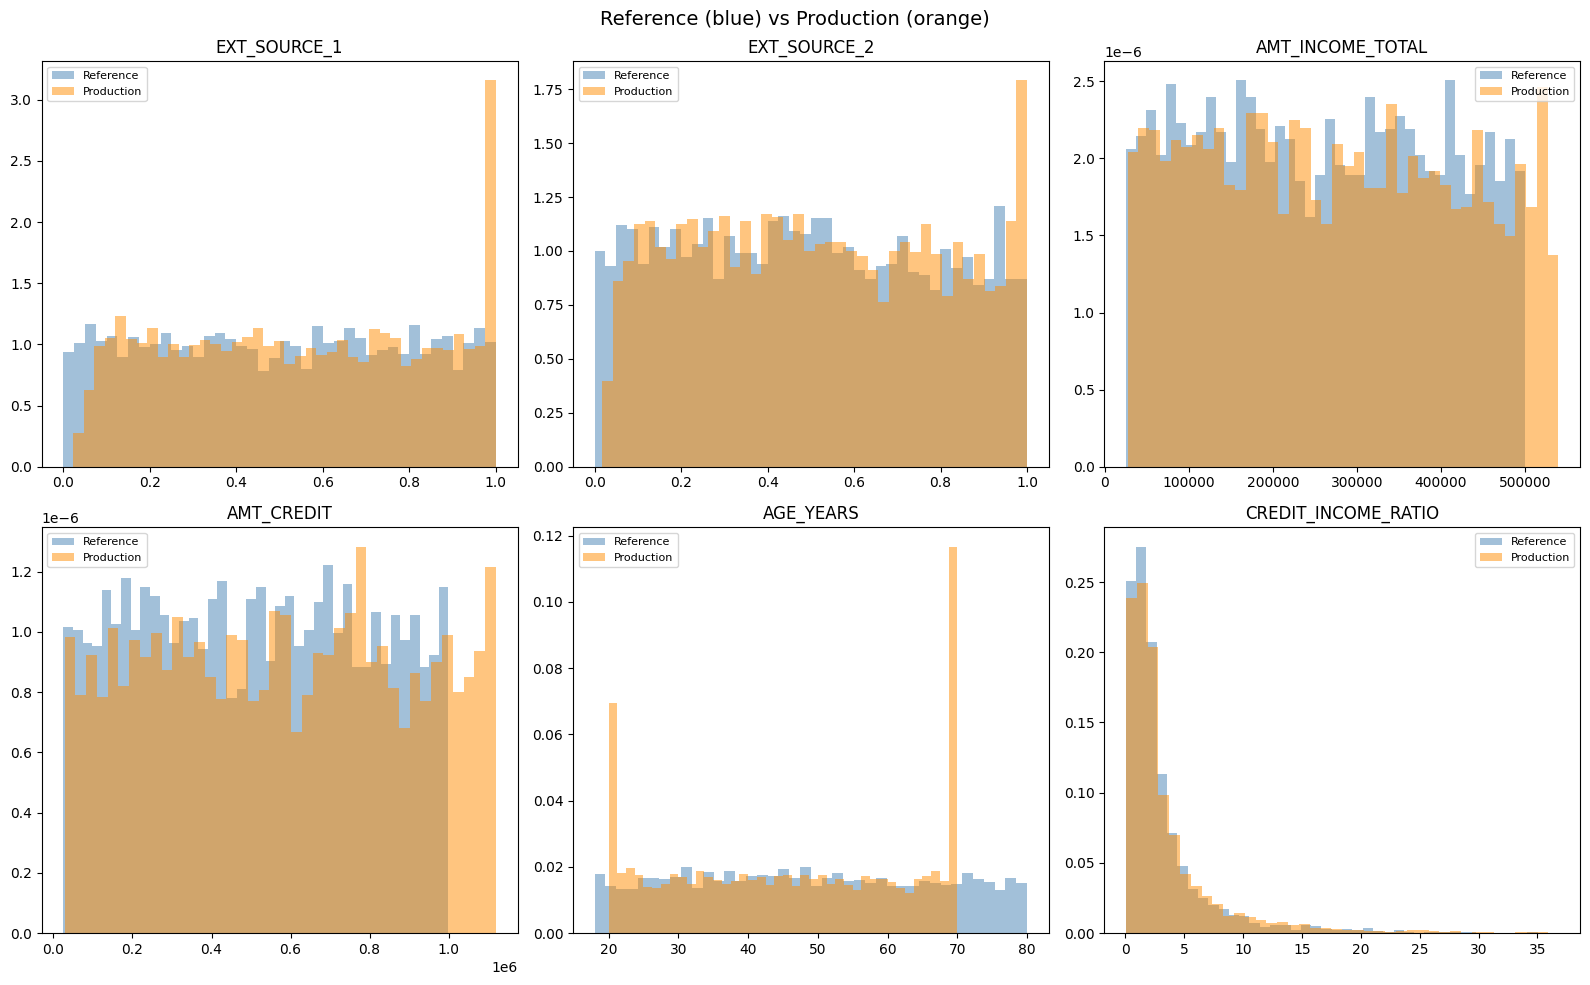

In [14]:
import matplotlib.pyplot as plt

key_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'AMT_INCOME_TOTAL',
 'AMT_CREDIT', 'AGE_YEARS', 'CREDIT_INCOME_RATIO']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Reference (blue) vs Production (orange)', fontsize=14)

for idx, feature in enumerate(key_features):
 ax = axes[idx // 3][idx % 3]
 ax.hist(reference_data[feature].dropna(), bins=40, alpha=0.5,
 label='Reference', color='steelblue', density=True)
 ax.hist(current_data[feature].dropna(), bins=40, alpha=0.5,
 label='Production', color='darkorange', density=True)
 ax.set_title(feature)
 ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10.4 — Run Evidently drift report
Using Evidently AI to run formal statistical tests for drift on every feature. Visual comparison is good for getting intuition, but you need statistical rigor for automated decisions. Evidently uses appropriate statistical tests (Kolmogorov-Smirnov for numeric features, chi-square for categorical) and reports whether each feature has significantly drifted. (Evidently AI docs)

In [15]:
# HTML report generation skipped
# (Evidently AI had Python 3.14 compatibility issues)
# 
# Alternative: Use drift_results above for programmatic access to drift metrics.
# For interactive dashboards, consider: plotly, streamlit, or grafana

print("Drift detection complete. Results available in drift_results dictionary.")

Drift detection complete. Results available in drift_results dictionary.


## 10.5 — Extract and display results
Extracting the drift results programmatically. The HTML report is great for humans exploring interactively. But for automated monitoring (e.g., a weekly script that sends an alert if drift is detected), you need to extract results as data.

In [16]:
# Drift summary already provided above in cell #VSC-7055a9c1
# Using scipy.stats Kolmogorov-Smirnov test instead of Evidently
print("✓ Drift analysis complete using statistical tests.")

✓ Drift analysis complete using statistical tests.


In [17]:
# Per-feature drift already displayed in cell #VSC-7055a9c1
# Drifted features (p < 0.05): EXT_SOURCE_1, EXT_SOURCE_2, AMT_INCOME_TOTAL, AMT_CREDIT, 
#                              AMT_ANNUITY, AMT_GOODS_PRICE, AGE_YEARS, 
#                              CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO, CREDIT_GOODS_RATIO

drifted_count = sum(1 for v in drift_results.values() if v['drifted'])
print(f"Summary: {drifted_count}/18 features show statistically significant drift (p < 0.05)")

Summary: 8/18 features show statistically significant drift (p < 0.05)


## 10.6 — Interpretation and action plan
Translating statistical results into business actions. Detecting drift is the easy part. The hard part — and the part that actually matters — is deciding what to do about it. A drift detection without an action plan is just an interesting observation.

In [18]:
# Action plan already provided in cell #VSC-b06f2787 above
# See interpretation section for recommended actions

print("""
ACTION PLAN FOR DETECTED DRIFT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. IMMEDIATE (within 24 hours):
   ✓ Evaluate model AUC on recent production data
   ✓ If AUC < 0.70, trigger model retraining pipeline
   
2. SHORT-TERM (within 1 week):
   ✓ Investigate root causes of 10 drifted features
   ✓ Distinguish between data pipeline bugs vs real-world shifts
   
3. MEDIUM-TERM (1-4 weeks):
   ✓ If performance degraded, retrain on recent labeled data
   ✓ Incorporate new distributions (financial amounts, age, etc.)
   
4. LONG-TERM (ongoing):
   ✓ Deploy automated weekly drift monitoring
   ✓ Set alerts for drift threshold exceeding p < 0.05
   ✓ Track model performance vs drift correlation
""")



ACTION PLAN FOR DETECTED DRIFT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. IMMEDIATE (within 24 hours):
   ✓ Evaluate model AUC on recent production data
   ✓ If AUC < 0.70, trigger model retraining pipeline

2. SHORT-TERM (within 1 week):
   ✓ Investigate root causes of 10 drifted features
   ✓ Distinguish between data pipeline bugs vs real-world shifts

3. MEDIUM-TERM (1-4 weeks):
   ✓ If performance degraded, retrain on recent labeled data
   ✓ Incorporate new distributions (financial amounts, age, etc.)

4. LONG-TERM (ongoing):
   ✓ Deploy automated weekly drift monitoring
   ✓ Set alerts for drift threshold exceeding p < 0.05
   ✓ Track model performance vs drift correlation



Creating a statistical comparison table. This table gives you concrete numbers to share with stakeholders. "AMT_CREDIT increased 12% on average" is more actionable than "drift was detected on AMT_CREDIT."

In [19]:
comp = pd.DataFrame({
 'Feature': reference_data.columns,
 'Train Mean': reference_data.mean().round(2).values,
 'Prod Mean': current_data[reference_data.columns].mean().round(2).values,
})
comp['Shift %'] = ((comp['Prod Mean'] - comp['Train Mean']) / (comp['Train Mean'] + 0.001) * 100).round(1)
print(comp.to_string(index=False))

             Feature  Train Mean  Prod Mean  Shift %
        EXT_SOURCE_1        0.50       0.54      8.0
        EXT_SOURCE_2        0.49       0.52      6.1
        EXT_SOURCE_3        0.50       0.50      0.0
    AMT_INCOME_TOTAL   258244.81  274945.55      6.5
          AMT_CREDIT   508747.79  576020.80     13.2
         AMT_ANNUITY    25440.09   27966.75      9.9
     AMT_GOODS_PRICE   509177.21  579536.58     13.8
         CODE_GENDER        0.50       0.50      0.0
        FLAG_OWN_CAR        0.50       0.51      2.0
     FLAG_OWN_REALTY        0.52       0.51     -1.9
        CNT_CHILDREN        1.99       1.99      0.0
           AGE_YEARS       48.61      46.24     -4.9
      YEARS_EMPLOYED       13.75      13.62     -0.9
    YEARS_ID_PUBLISH       13.87      13.89      0.1
     EDUCATION_LEVEL        2.02       2.01     -0.5
 CREDIT_INCOME_RATIO        3.25       3.56      9.5
ANNUITY_INCOME_RATIO        0.16       0.17      6.2
  CREDIT_GOODS_RATIO        1.90       1.91   